In [15]:
import matplotlib.pyplot as plt
import scienceplots
# plt.style.use('science')
plt.style.use(['science', 'nature', 'grid'])

from matplotlib.lines import Line2D

import numpy as np
import pandas as pd

In [16]:
WIDTH = 6.0 
HEIGHT = 5.0

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

# For Thesis

## Landau Damping

In [17]:
closures = [
    "Gram",
    "ExtGram",
    "Grad"
]
T_end = 25.0

x_lower = 0.0; x_upper = 12.566370614359172
# base_tree_level = 6
# polydeg = 3
base_tree_level = 8 #!6
polydeg = 1 #!3
Kn = 1.0

epsilon = 0.01
k = 0.5
rho_0 = 1.0
v_0 = 0.0
theta_0 = 1.0

markers = ['x', 'o', '^', 's', 'D', 'v']
colors = ['blue', 'orange', 'green', 'red', 'purple', 'cyan']

/tmp/ipykernel_15606/1182424149.py:19: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_15606/1182424149.py:43: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


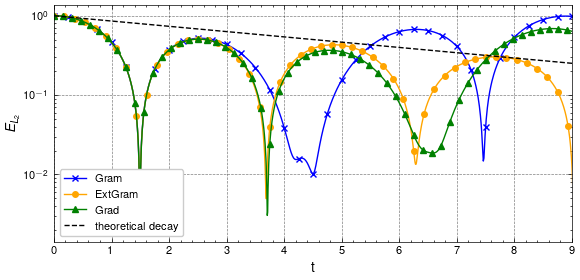

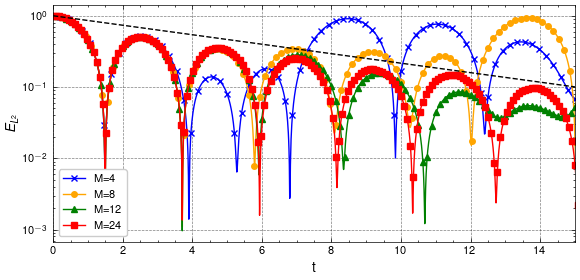

In [18]:
M = 6
gamma = -0.1533

fig, axs = plt.subplots(figsize=(WIDTH, .6*HEIGHT))#!nrows=2)
for i, closure in enumerate(closures):
    # file = f"../out/VlasovPoisson/LandauDamping/energy_moments_closure{closure}_T{T_end}_M{M}_k{k}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
    file = f"../out/VlasovPoisson/LandauDamping/energy_moments_solution_M{M}_closure{closure}_Kn{Kn}_T_end{T_end}_rho_0{rho_0}_v_0{v_0}_theta_0{theta_0}_epsilon{epsilon}_k{k}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
    data = pd.read_csv(file)

    axs.plot(data["time"], data["E_L2"] / data["E_L2"][0], marker=markers[i], color=colors[i], markevery=25, label=closure)
axs.plot(data["time"], np.exp(gamma * data["time"]), 'k--', label="theoretical decay")
axs.set_xlim(0, 9)
axs.set_yscale("log")
axs.set_xlabel("t")
axs.set_ylabel("$E_{L_2}$")
axs.legend(loc='lower left')
fig.tight_layout()
fig.savefig(f"../out/Figures/LandauDamping/LandauDamping_M{M}_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
fig.show()


Moments = [4, 8, 12, 24]
closure = 'ExtGram'
# base_tree_level = 8 #!6
# polydeg = 1 #!3
# Kn = 1.0

fig, axs = plt.subplots(figsize=(WIDTH, .6*HEIGHT))
for i, M in enumerate(Moments):
    file = f"../out/VlasovPoisson/LandauDamping/energy_moments_solution_M{M}_closure{closure}_Kn{Kn}_T_end{T_end}_rho_0{rho_0}_v_0{v_0}_theta_0{theta_0}_epsilon{epsilon}_k{k}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
    data = pd.read_csv(file)

    axs.plot(data["time"], data["E_L2"] / data["E_L2"][0], marker=markers[i], markevery=25, color=colors[i], label=f'M={M}')

axs.plot(data["time"], np.exp(gamma * data["time"]), 'k--')
axs.set_yscale("log")
axs.set_xlim(0, 15)
axs.set_xlabel("t")
axs.set_ylabel("$E_{L^2}$")
axs.legend(loc='lower left')
fig.tight_layout()
fig.savefig(f"../out/Figures/LandauDamping/LandauDamping_Even_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
fig.show()

## Two-Stream Instability

In [19]:
def get_E_num(closure, T_end, M, k_, epsilon, polydeg, base_tree_level):
    file = f"../out/VlasovPoisson/TwoStreamInstability/energy_moments_closure{closure}_T{T_end}_M{M}_k{k_}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}.csv"
    data = pd.read_csv(file)

    return data

/tmp/ipykernel_15606/1584766178.py:17: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


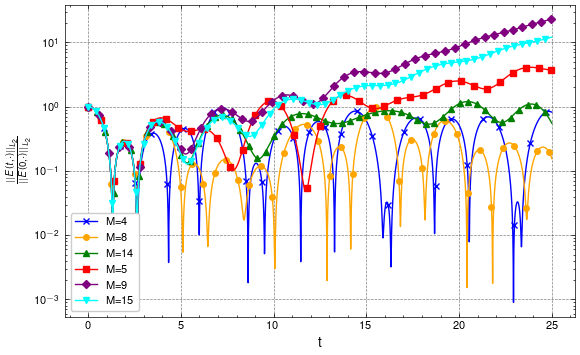

In [20]:
base_tree_level = 8
polydeg = 1
closure = "ExtGram"
Moments = [4, 8, 14, 5, 9, 15]

fig, axs = plt.subplots(figsize=(WIDTH, 0.75*HEIGHT))
for i, M in enumerate(Moments):
    data = get_E_num(closure, T_end, M, k, epsilon, polydeg, base_tree_level)
    axs.plot(data["time"], data["E_L2"] / data["E_L2"][0], marker=markers[i], markevery=100, color=colors[i], label=f'M={M}')
axs.set_yscale("log")
axs.set_xlabel("t")
axs.set_ylabel("$\\frac{||E(t,\cdot)||_{L_2}}{||E(0,\cdot)||_{L_2}}$")
# axs.set_title(closure)
axs.legend(loc='lower left')
fig.savefig(f"../out/Figures/TwoStreamInstability/TwoStreamInstability_CompareMoments_{closure}_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
fig.tight_layout()
fig.show()

<>:11: SyntaxWarning: invalid escape sequence '\c'
<>:11: SyntaxWarning: invalid escape sequence '\c'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_1482/2855607525.py:11: SyntaxWarning: invalid escape sequence '\c'
  axs.set_ylabel("$\\frac{||E(t,\cdot)||_{L_2}}{||E(0,\cdot)||_{L_2}}$")
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_1482/2855607525.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


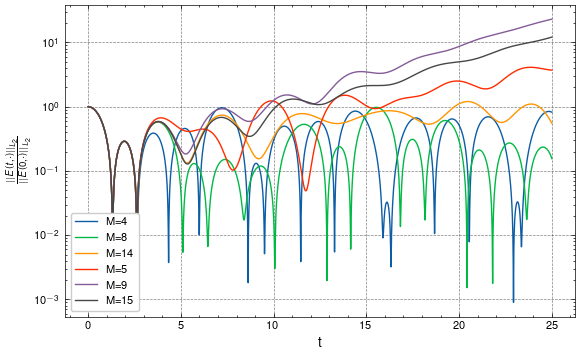

In [13]:
base_tree_level = 8
polydeg = 1
closure = "ExtGram"

fig, axs = plt.subplots(figsize=(WIDTH, 0.75*HEIGHT))
for i, M in enumerate(Moments):
    data = get_E_num(closure, T_end, M, k, epsilon, polydeg, base_tree_level)
    axs.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=f'M={M}')
axs.set_yscale("log")
axs.set_xlabel("t")
axs.set_ylabel("$\\frac{||E(t,\cdot)||_{L_2}}{||E(0,\cdot)||_{L_2}}$")
# axs.set_title(closure)
axs.legend(loc='lower left')
# fig.savefig(f"../out/Figures/TwoStreamInstability/TwoStreamInstability_CompareMoments_{closure}_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
fig.tight_layout()
fig.show()

# Landau damping

In [14]:
closures = [
    "Gram",
    "ExtGram",
    "Grad"
]
T_end = 25.0
M_vec = [4, 6, 8, 10, 12, 14, 24]

x_lower = 0.0; x_upper = 12.566370614359172
base_tree_level = 6
polydeg = 3

epsilon = 0.01
k = 0.5

M=4, k=0.5


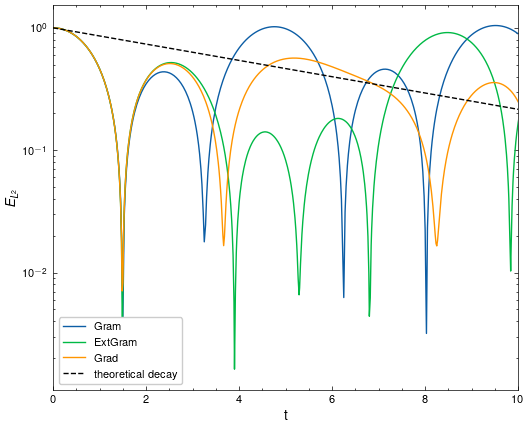

M=6, k=0.5


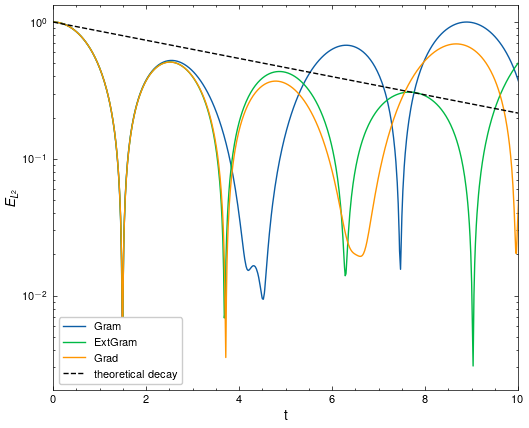

M=8, k=0.5


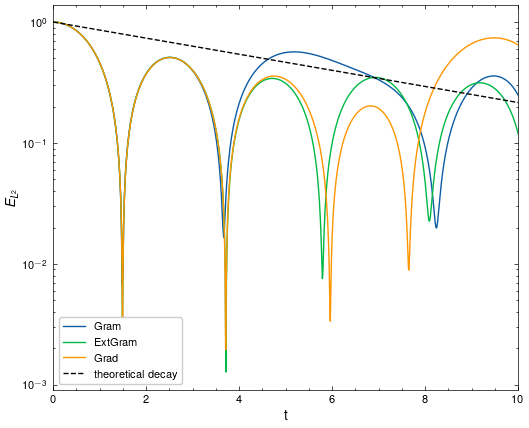

M=10, k=0.5


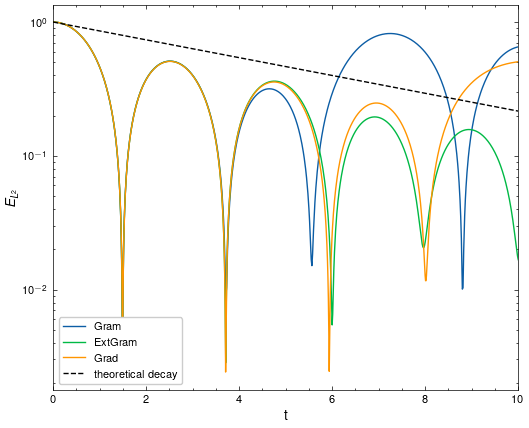

M=12, k=0.5


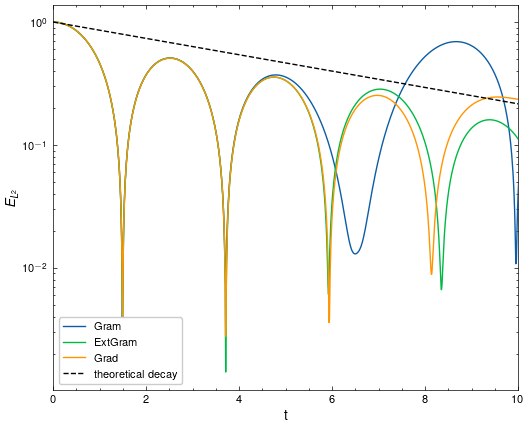

M=14, k=0.5


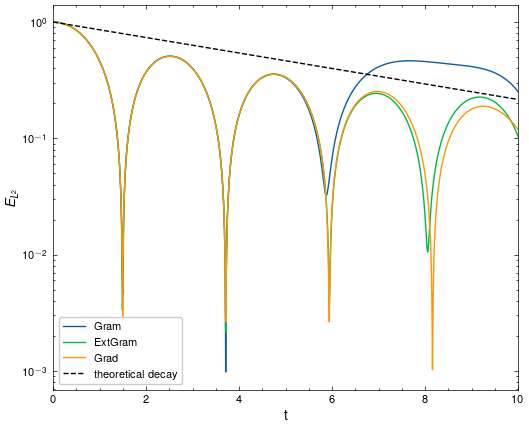

M=24, k=0.5


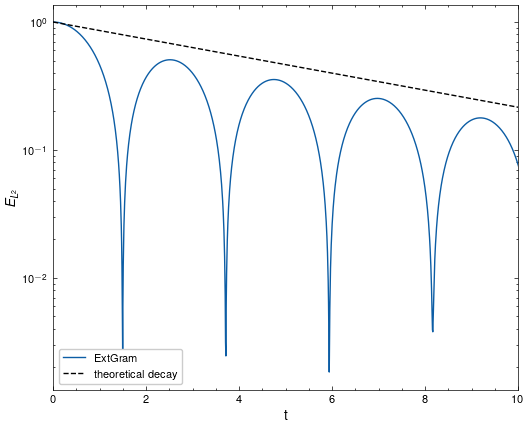

In [15]:
gamma = -0.1533
for M in M_vec:
    print(f"M={M}, k={k}")

    plt.figure()
    for closure in closures:
        if M == 24 and closure in ["Gram", "Grad"]:
            continue
        file = f"../out/VlasovPoisson/LandauDamping/energy_moments_closure{closure}_T{T_end}_M{M}_k{k}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
        data = pd.read_csv(file)

        plt.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=closure)

    plt.plot(data["time"], np.exp(gamma * data["time"]), 'k--', label="theoretical decay")
    plt.xlim(0, 10)
    plt.yscale("log")
    plt.xlabel("t")
    plt.ylabel("$E_{L^2}$")
    # plt.title(f"M={M}")
    plt.legend(loc='lower left')
    plt.grid()
    # plt.savefig(f"../out/Figures/LandauDamping/LandauDamping_M{M}_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
    plt.show()

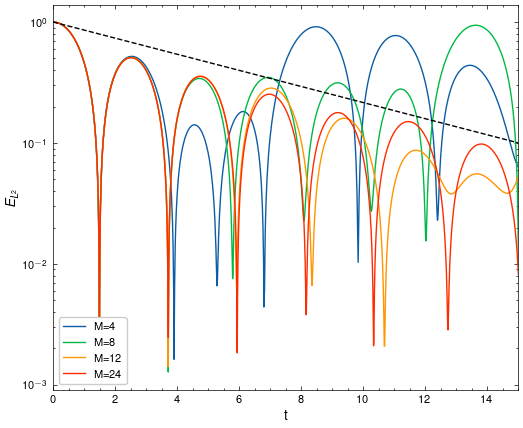

In [16]:
for closure in ["ExtGram"]:
    plt.figure()
    for M in [4, 8, 12, 24]:
        file = f"../out/VlasovPoisson/LandauDamping/energy_moments_closure{closure}_T{T_end}_M{M}_k{k}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
        data = pd.read_csv(file)

        plt.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=f'M={M}')

    plt.plot(data["time"], np.exp(gamma * data["time"]), 'k--')
    plt.yscale("log")
    plt.xlim(0, 15)
    plt.xlabel("t")
    plt.ylabel("$E_{L^2}$")
    # plt.title(f"M={M}")
    plt.legend(loc='lower left')
    plt.grid()
    # plt.savefig(f"../out/Figures/LandauDamping/LandauDamping_Even_{closure}_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
    plt.show()

In [17]:
T_end = 25.0

base_tree_level = 6
polydeg = 3

epsilon = 0.01
k = 0.5

<>:41: SyntaxWarning: invalid escape sequence '\c'
<>:41: SyntaxWarning: invalid escape sequence '\c'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_1482/2263685852.py:41: SyntaxWarning: invalid escape sequence '\c'
  ax_E.set_ylabel("$\\frac{||E(t,\cdot)||_{L_2}}{||E(0,\cdot)||_{L_2}}$")
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_1482/2263685852.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_E.show()


Recursion times
----------------
M=4: t_rec=0.45
M=6: t_rec=0.4916329105071289
M=8: t_rec=0.5
M=10: t_rec=0.6792352507097078
M=12: t_rec=0.6759131803719721


/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_1482/2263685852.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_E.show()


Recursion times
----------------
M=4: t_rec=0.5
M=6: t_rec=0.6659122167187314
M=8: t_rec=0.6772527984869942
M=10: t_rec=6.873857449962039
M=12: t_rec=8.121664697850717


/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_1482/2263685852.py:63: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_recursion.show()


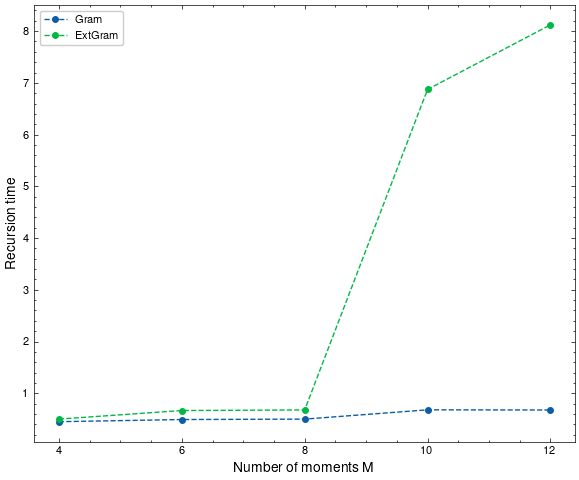

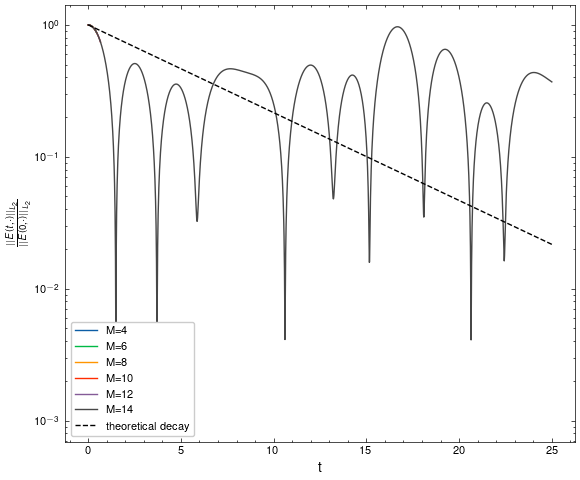

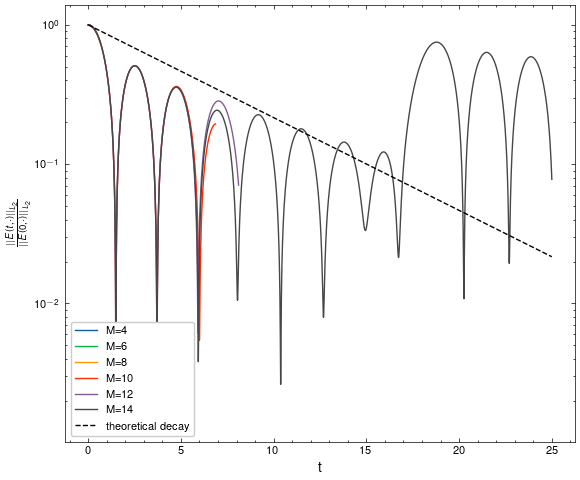

In [18]:
# Even Order Moments

closures = [
    "Gram",
    "ExtGram"
]
M_vec = [4, 6, 8, 10, 12, 14]

# recursion time
rel_tol = 0.1
gamma = -0.1533  # theoretical damping rate for k=0.5
# reference solution
# Todo: Compare with Grad?
file = f"../out/VlasovPoisson/LandauDamping/energy_moments_closureExtGram_T{T_end}_M{M_vec[-1]}_k{k}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
data = pd.read_csv(file)
E_ref = data["E_L2"].to_numpy() / data["E_L2"][0]

fig_recursion, ax_recursion = plt.subplots()
for closure in closures:
    recursion_time = []
    fig_E, ax_E = plt.subplots()
    for M in M_vec:

        file = f"../out/VlasovPoisson/LandauDamping/energy_moments_closure{closure}_T{T_end}_M{M}_k{k}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
        data = pd.read_csv(file)
        # plt.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=f'M={M}')

        # recursion time: time until which the solution is accurate
        if M != M_vec[-1]:
            E_num = data["E_L2"].to_numpy() / data["E_L2"][0]
            for t_idx in range(len(E_num)):
                if (E_ref[t_idx] - E_num[t_idx]) * np.exp(-gamma * data["time"][t_idx]) > rel_tol:
                    recursion_time.append(data["time"][t_idx])
                    ax_E.plot(data["time"][:4//3*t_idx], data["E_L2"][:4//3*t_idx] / data["E_L2"][0], label=f'M={M}')
                    break
        else:
            ax_E.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=f'M={M}')
            ax_E.plot(data["time"], np.exp(gamma * data["time"]), "k--", label="theoretical decay")
    ax_E.set_yscale("log")
    ax_E.set_xlabel("t")
    ax_E.set_ylabel("$\\frac{||E(t,\cdot)||_{L_2}}{||E(0,\cdot)||_{L_2}}$")
    # ax_E.set_title(closure)
    ax_E.legend(loc='lower left')
    ax_E.grid()
    fig_E.savefig(f"../out/Figures/LandauDamping/LandauDamping_Even_Closure{closure}_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
    fig_E.tight_layout()
    fig_E.show()

    print("Recursion times")
    print("----------------")
    for i, M in enumerate(M_vec[:-1]):
        print(f"M={M}: t_rec={recursion_time[i]}")

    ax_recursion.plot(M_vec[:-1], recursion_time, "o--", label=f"{closure}")
ax_recursion.set_xlabel("Number of moments M")
ax_recursion.set_ylabel("Recursion time")
ax_recursion.set_xticks(M_vec[:-1])
# ax_recursion.set_title(f"k={k}")
ax_recursion.legend()
ax_recursion.grid()
fig_recursion.savefig(f"../out/Figures/LandauDamping/LandauDamping_RecursionTime_Even_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
fig_recursion.tight_layout()
fig_recursion.show()

In [19]:
# M_vec = [5, 7, 9, 11, 13, 15]
# k = 0.5
# gamma = -0.1533
# for M in M_vec:
#     print(f"M={M}, k={k}")

#     plt.figure()
#     for closure in closures:
#         # if (closure == "Grad" and M % 2 != 0) or (closure == "Grad" and M > 6):
#         #     continue  # skip odd M for Grad closure
#         file = f"../out/VlasovPoisson/LandauDamping/energy_moments_closure{closure}_T{T_end}_M{M}_k{k}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
#         data = pd.read_csv(file)

#         plt.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=closure)

#     plt.plot(data["time"], np.exp(gamma * data["time"]), 'k--', label="theoretical decay")
#     plt.yscale("log")
#     plt.xlabel("t")
#     plt.ylabel("$E_{L^2}$")
#     # plt.title(f"M={M}")
#     plt.legend(loc='lower left')
#     plt.grid()
#     plt.savefig(f"../out/Figures/LandauDamping_M{M}_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
#     plt.show()

In [20]:
# # Odd Order Moments

# closures = [
#     "Gram",
#     "ExtGram",
#     # "Grad"
# ]
# M_vec = [5, 7, 9, 11, 13, 15]

# # recursion time
# rel_tol = 0.1
# gamma = -0.1533  # theoretical damping rate for k=0.5
# # reference solution
# # Todo: Compare with Grad?
# file = f"../out/VlasovPoisson/LandauDamping/energy_moments_closureExtGram_T{T_end}_M{M_vec[-1]}_k{k}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
# data = pd.read_csv(file)
# E_ref = data["E_L2"].to_numpy() / data["E_L2"][0]

# fig_recursion, ax_recursion = plt.subplots()
# for closure in closures:
#     recursion_time = []
#     fig_E, ax_E = plt.subplots()
#     for M in M_vec:

#         file = f"../out/VlasovPoisson/LandauDamping/energy_moments_closure{closure}_T{T_end}_M{M}_k{k}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
#         data = pd.read_csv(file)
#         # plt.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=f'M={M}')

#         # recursion time: time until which the solution is accurate
#         if M != M_vec[-1]:
#             E_num = data["E_L2"].to_numpy() / data["E_L2"][0]
#             for t_idx in range(len(E_num)):
#                 if (E_ref[t_idx] - E_num[t_idx]) * np.exp(-gamma * data["time"][t_idx]) > rel_tol:
#                     recursion_time.append(data["time"][t_idx])
#                     ax_E.plot(data["time"][:2*t_idx], data["E_L2"][:2*t_idx] / data["E_L2"][0], label=f'M={M}')
#                     # ax_E.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=f'M={M}')
#                     break
#         else:
#             ax_E.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=f'M={M}')
#             ax_E.plot(data["time"], np.exp(gamma * data["time"]), "k--", label="theoretical decay")
#     ax_E.set_yscale("log")
#     ax_E.set_xlabel("t")
#     ax_E.set_ylabel("$\\frac{||E(t,\cdot)||_{L_2}}{||E(0,\cdot)||_{L_2}}$")
#     # ax_E.set_title(closure)
#     ax_E.legend(loc='lower left')
#     ax_E.grid()
#     fig_E.savefig(f"../out/Figures/LandauDamping/LandauDamping_Odd_Closure{closure}_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
#     fig_E.tight_layout()
#     fig_E.show()

#     print("Recursion times")
#     print("----------------")
#     for i, M in enumerate(M_vec[:-1]):
#         print(f"M={M}: t_rec={recursion_time[i]}")

#     ax_recursion.plot(M_vec[:-1], recursion_time, "o--", label=f"{closure}")
# ax_recursion.set_xlabel("Number of moments M")
# ax_recursion.set_ylabel("Recursion time")
# ax_recursion.set_xticks(M_vec[:-1])
# # ax_recursion.set_title(f"k={k}")
# ax_recursion.legend()
# ax_recursion.grid()
# fig_recursion.savefig(f"../out/Figures/LandauDamping_RecursionTime_Odd_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
# fig_recursion.tight_layout()
# fig_recursion.show()

# Two-stream instability

In [21]:
T_end = 25.0

epsilon = 0.01
k = 0.5

In [22]:
def get_E_num(closure, T_end, M, k_, epsilon, polydeg, base_tree_level):
    file = f"../out/VlasovPoisson/TwoStreamInstability/energy_moments_closure{closure}_T{T_end}_M{M}_k{k_}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}.csv"
    data = pd.read_csv(file)

    return data

<>:18: SyntaxWarning: invalid escape sequence '\c'
<>:18: SyntaxWarning: invalid escape sequence '\c'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_1482/427747294.py:18: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel("$\\frac{||E(t,\cdot)||_{L_2}}{||E(0,\cdot)||_{L_2}}$")
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_1482/427747294.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Closure: Gram
Closure: ExtGram


/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_1482/427747294.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


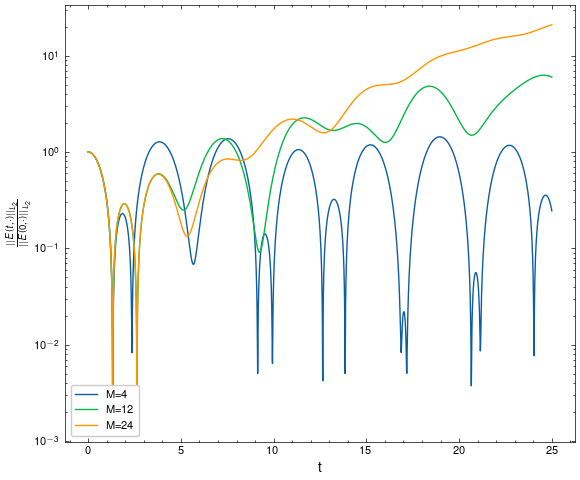

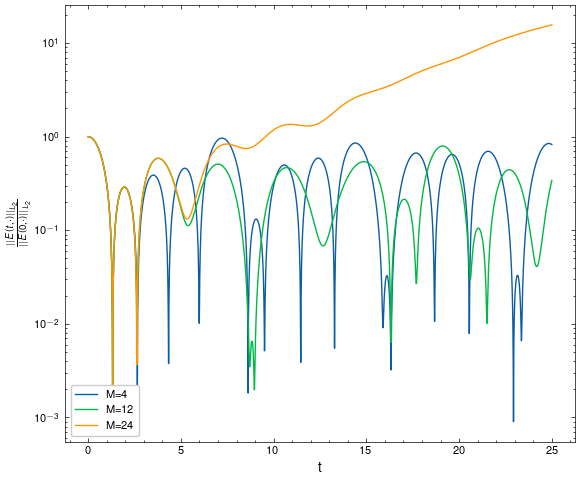

In [23]:
# Even Order Moments

closures =[
    "Gram",
    "ExtGram"
]
base_tree_level = 8
polydeg = 1

for closure in closures:
    print(f"Closure: {closure}")
    fig, ax = plt.subplots()
    for M in [4, 12, 24]:
        data = get_E_num(closure, T_end, M, k, epsilon, polydeg, base_tree_level)
        ax.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=f'M={M}')
    ax.set_yscale("log")
    ax.set_xlabel("t")
    ax.set_ylabel("$\\frac{||E(t,\cdot)||_{L_2}}{||E(0,\cdot)||_{L_2}}$")
    # ax.set_title(closure)
    ax.legend(loc='lower left')
    ax.grid()
    # fig.savefig(f"../out/Figures/TwoStreamInstability/TwoStreamInstability_Even_Closure{closure}_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
    fig.tight_layout()
    fig.show()

Closure: ExtGram


<>:15: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\c'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_1482/4095273976.py:15: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel("$\\frac{||E(t,\cdot)||_{L_2}}{||E(0,\cdot)||_{L_2}}$")
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_1482/4095273976.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


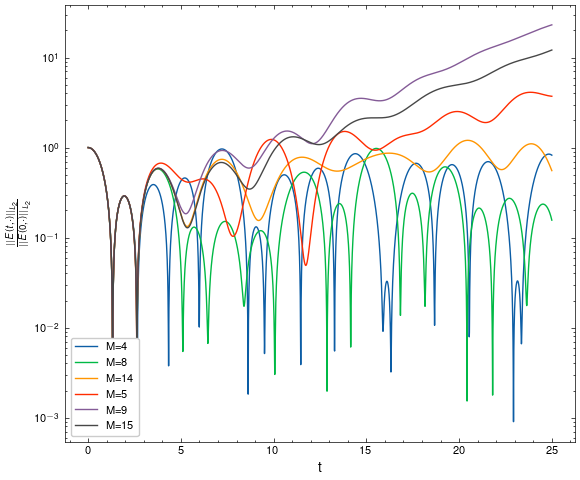

In [24]:
polydeg = 1

closures =[
    # "Gram",
    "ExtGram"
]
for closure in closures:
    print(f"Closure: {closure}")
    fig, ax = plt.subplots()
    for M in [4, 8, 14, 5, 9, 15]:
        data = get_E_num(closure, T_end, M, k, epsilon, polydeg, base_tree_level)
        ax.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=f'M={M}')
    ax.set_yscale("log")
    ax.set_xlabel("t")
    ax.set_ylabel("$\\frac{||E(t,\cdot)||_{L_2}}{||E(0,\cdot)||_{L_2}}$")
    # ax.set_title(closure)
    ax.legend(loc='lower left')
    ax.grid()
    # fig.savefig(f"../out/Figures/TwoStreamInstability/TwoStreamInstability_CompareMoments_{closure}_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
    fig.tight_layout()
    fig.show()